C:\Users\kelvi\AppData\Local\Temp\ipykernel_47352\427451365.py:125: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  sec_ret_daily   = df[assets].pct_change().replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)


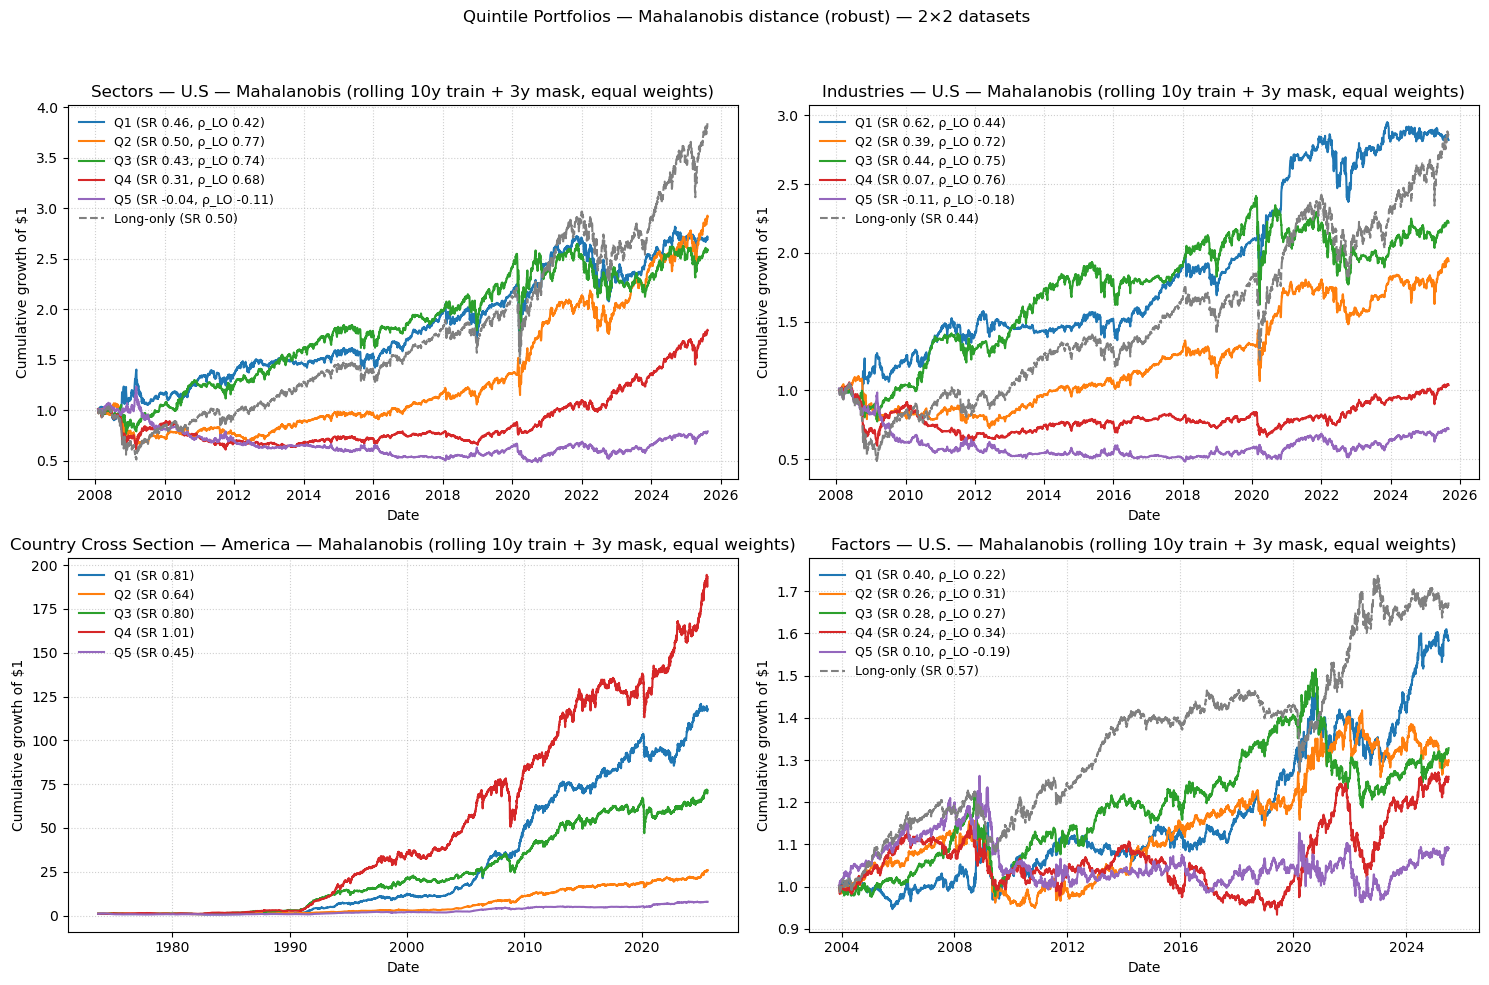

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


PATH_MACRO = Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\state_z_america.xlsx")

DATASETS = [
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Sectors\Per Region\Sector North America.xlsx"),
     "auto", "Sectors — U.S", True),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Industries\Developped Countries Industry.xlsx"),
     "auto", "Industries — U.S", True),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Cross Section Countries\Americas CS Country.xlsx"),
     "auto", "Country Cross Section — America", False),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\North_America_6_Factors_Daily_clean.xlsx"),
     "auto", "Factors — U.S.", True),
]

TRAIN_YEARS = 10
MASK_YEARS  = 3

MIN_COVERAGE = 1.0  


def ann_sr(s: pd.Series) -> float:
    s = pd.Series(s).dropna()
    if s.empty: return np.nan
    sig = s.std()
    return (s.mean()/sig)*np.sqrt(252) if sig != 0 else np.nan

def clean_corr(a: pd.Series, b: pd.Series) -> float:
    df = pd.concat([a, b], axis=1).dropna()
    df = df[(df != 0).any(axis=1)]
    return df.corr().iloc[0,1] if not df.empty else np.nan

def make_quintiles(ordered_months):
    n = len(ordered_months)
    if n == 0: return {1:[],2:[],3:[],4:[],5:[]}
    k20 = max(int(0.20*n), 1)
    q1 = ordered_months[:k20]
    q5 = ordered_months[-k20:]
    mid = ordered_months[k20:-k20]
    if len(mid) >= 3:
        q2, q3, q4 = np.array_split(np.array(mid), 3)
    else:
        q2, q3, q4 = [], mid, []
    return {1:list(q1),2:list(q2),3:list(q3),4:list(q4),5:list(q5)}


def load_macro_states(path_macro: Path) -> pd.DataFrame:
    Z = pd.read_excel(path_macro)
    if "Month" not in Z.columns:
        for cand in ["month","MONTH","Date","Dates"]:
            if cand in Z.columns:
                Z = Z.rename(columns={cand: "Month"})
                break
    if "Month" not in Z.columns:
        raise ValueError("Macro file must have a 'Month' column (or Date/Dates).")
    Z["Month"] = pd.to_datetime(Z["Month"], errors="coerce").dt.to_period("M")
    Z = Z.set_index("Month").sort_index()
    macro_cols = [c for c in Z.columns if pd.api.types.is_numeric_dtype(Z[c])]
    if not macro_cols:
        raise ValueError("No numeric macro columns found in macro file.")
    return Z[macro_cols].astype(float)

def _parse_date_column(df: pd.DataFrame) -> pd.DatetimeIndex:
    date_col = next((c for c in ["Dates", "Date", "DATE", "date", "dt"] if c in df.columns), None)
    if date_col is None:
        raise ValueError("No date column named Dates/Date/DATE/date/dt found.")
    col = df[date_col]
    if np.issubdtype(col.dtype, np.datetime64):
        dt = pd.to_datetime(col, errors="coerce")
    else:
        as_str = col.astype(str).str.strip()
        if as_str.str.fullmatch(r"\d{8}").fillna(False).all():
            dt = pd.to_datetime(as_str, format="%Y%m%d", errors="coerce")
        else:
            dt = pd.to_datetime(col, errors="coerce")
    if dt.isna().all():
        raise ValueError("All dates failed to parse. Check the date format.")
    return dt

def load_assets_auto(path: Path, min_coverage: float = MIN_COVERAGE):

    df = pd.read_excel(path)
    df.columns = [c.strip() for c in df.columns]
    std_cols = ["Mkt-RF","SMB","HML","RMW","CMA","Mom","RF"]
    present  = [c for c in std_cols if c in df.columns]

    dt = _parse_date_column(df)
    date_col = next(c for c in ["Dates", "Date", "DATE", "date", "dt"] if c in df.columns)
    df = df.assign(**{date_col: dt}).dropna(subset=[date_col]).set_index(date_col).sort_index()

    if len(present) >= 5:
        # FF6-like
        sample = df[present].select_dtypes(include=[np.number]).stack()
        if sample.abs().median() > 0.05:
            df[present] = df[present].astype(float) / 100.0
        else:
            df[present] = df[present].astype(float)
        assets = [c for c in present if c != "RF"]
        sec_ret_daily   = df[assets].replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)
        sec_ret_monthly = (1.0 + sec_ret_daily).resample("ME").prod() - 1.0
    else:
        # Levels -> returns
        assets = [c for c in df.columns if c not in ["Dates","Date","DATE","date","dt"]
                  and pd.api.types.is_numeric_dtype(df[c])]
        if not assets:
            raise ValueError(f"No numeric asset columns found in {path.name}")
        sec_ret_daily   = df[assets].pct_change().replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)
        sec_ret_monthly = (1.0 + sec_ret_daily).resample("ME").prod() - 1.0

    # keep months with enough coverage
    need = max(1, int(np.ceil(min_coverage * len(assets))))
    good_months = sec_ret_monthly.notna().sum(axis=1) >= need
    sec_ret_monthly = sec_ret_monthly.loc[good_months]
    sector_months   = sec_ret_monthly.index.to_period("M")

    # trim daily to those months
    keep = sec_ret_daily.index.to_period("M").isin(sector_months)
    sec_ret_daily = sec_ret_daily.loc[keep]

    sec_ret_monthly.index = sec_ret_monthly.index.to_period("M")
    return sec_ret_daily, sec_ret_monthly, assets, sector_months


def mahalanobis_distances(F_train: pd.DataFrame, x0: pd.Series, ridge: float = 1e-8) -> pd.Series:

    common = F_train.columns.intersection(x0.index)
    if len(common) == 0 or F_train.shape[0] == 0:
        return pd.Series(dtype=float)

    X = F_train[common].values.astype(float)     # (n, p)
    x = x0[common].values.astype(float).reshape(1, -1)

    if X.shape[1] == 0:
        return pd.Series(dtype=float)

    Σ = np.cov(X, rowvar=False)
    Σ = np.atleast_2d(np.asarray(Σ))

    p = Σ.shape[0]
    if Σ.shape[0] != Σ.shape[1] or p != X.shape[1]:
        var = X.var(axis=0, ddof=1)
        var[var <= 0] = ridge
        Σ = np.diag(var)
        p = Σ.shape[0]

    Σ = Σ + ridge * np.eye(p)

    try:
        Σ_inv = np.linalg.inv(Σ)
    except np.linalg.LinAlgError:
        Σ_inv = np.linalg.pinv(Σ)

    diffs = X - x
    d2 = np.einsum("ij,jk,ik->i", diffs, Σ_inv, diffs)
    d = np.sqrt(np.clip(d2, 0, np.inf))
    return pd.Series(d, index=F_train.index).sort_values()


def build_quintile_series_rolling_maha_equal(path: Path,
                                             train_years: int = TRAIN_YEARS,
                                             mask_years: int  = MASK_YEARS,
                                             min_coverage: float = MIN_COVERAGE):
    sec_ret_daily, sec_ret_monthly, assets, sector_months = load_assets_auto(path, min_coverage=min_coverage)

    Z_all = load_macro_states(PATH_MACRO)
    Z = Z_all.reindex(sector_months).ffill()

    min_m = max(sector_months.min(), Z.index.min())
    first_eval = (min_m.asfreq("M") + (train_years + mask_years) * 12)
    months_bt = sector_months[(sector_months >= first_eval)]

    returns_by_q = {q: [] for q in range(1,6)} 
    for m in months_bt:
        tr_end   = (m - mask_years)              
        tr_start = tr_end - (train_years * 12) + 1

        F_train = Z.loc[(Z.index >= tr_start) & (Z.index <= tr_end)].dropna(how="any")
        if F_train.shape[0] < 2:  
            continue

        x0 = Z.loc[m].dropna()
        if x0.empty:
            continue

        d = mahalanobis_distances(F_train, x0, ridge=1e-8)
        if d.empty:
            continue

        buckets = make_quintiles(list(d.index))

        next_m = m + 1
        dts = sec_ret_daily.index[sec_ret_daily.index.to_period("M") == next_m]
        if len(dts) == 0:
            continue
        Rm = sec_ret_daily.loc[dts, assets]

        for q in [1,2,3,4,5]:
            q_months = buckets[q]
            if len(q_months) == 0:
                q_daily = pd.Series(0.0, index=dts)
            else:
                idx_sim_next = (pd.PeriodIndex(q_months, freq="M") + 1)
                idx_sim_next = sec_ret_monthly.index.intersection(idx_sim_next)
                if len(idx_sim_next) == 0:
                    q_daily = pd.Series(0.0, index=dts)
                else:
                    signs = {}
                    for a in assets:
                        mu = sec_ret_monthly.loc[idx_sim_next, a].mean()
                        signs[a] = np.sign(mu) if np.isfinite(mu) else 0.0
                    w_assets = pd.Series(signs, index=assets, dtype=float)
                    q_daily = (Rm * w_assets).mean(axis=1)

            returns_by_q[q].extend(q_daily.items())

    q_series = {q: pd.Series(dict(returns_by_q[q])).sort_index() for q in range(1,6)}
    for q in q_series:
        q_series[q].index = pd.to_datetime(q_series[q].index)

    common_idx = None
    for q in q_series:
        idx = q_series[q].index
        common_idx = idx if common_idx is None else common_idx.intersection(idx)
    for q in q_series:
        q_series[q] = q_series[q].reindex(common_idx).fillna(0.0)

    long_only = sec_ret_daily[assets].mean(axis=1).reindex(common_idx).fillna(0.0)

    return q_series, long_only

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=False)
axes = axes.ravel()

for ax, (path, kind, title, show_lo) in zip(axes, DATASETS):
    q_series, long_only = build_quintile_series_rolling_maha_equal(
        path=path,
        train_years=TRAIN_YEARS,
        mask_years=MASK_YEARS,
        min_coverage=MIN_COVERAGE
    )

    for q in [1,2,3,4,5]:
        sr = ann_sr(q_series[q])
        if show_lo:
            rho = clean_corr(q_series[q], long_only)
            lbl = f"Q{q} (SR {sr:.2f}, ρ_LO {rho:.2f})"
        else:
            lbl = f"Q{q} (SR {sr:.2f})"
        ax.plot(q_series[q].index, (1+q_series[q]).cumprod(), label=lbl)

    if show_lo:
        sr_lo = ann_sr(long_only)
        ax.plot(long_only.index, (1+long_only).cumprod(), color="gray", ls="--",
                label=f"Long-only (SR {sr_lo:.2f})")

    ax.set_title(f"{title} — Mahalanobis (rolling {TRAIN_YEARS}y train + {MASK_YEARS}y mask, equal weights)")
    ax.set_xlabel("Date"); ax.set_ylabel("Cumulative growth of $1")
    ax.grid(ls=":", alpha=.6)
    ax.legend(frameon=False, loc="upper left", fontsize=9)

plt.suptitle("Quintile Portfolios — Mahalanobis distance (robust) — 2×2 datasets", y=0.98)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


C:\Users\kelvi\AppData\Local\Temp\ipykernel_47352\424042808.py:124: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  sec_ret_daily   = df[assets].pct_change().replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)


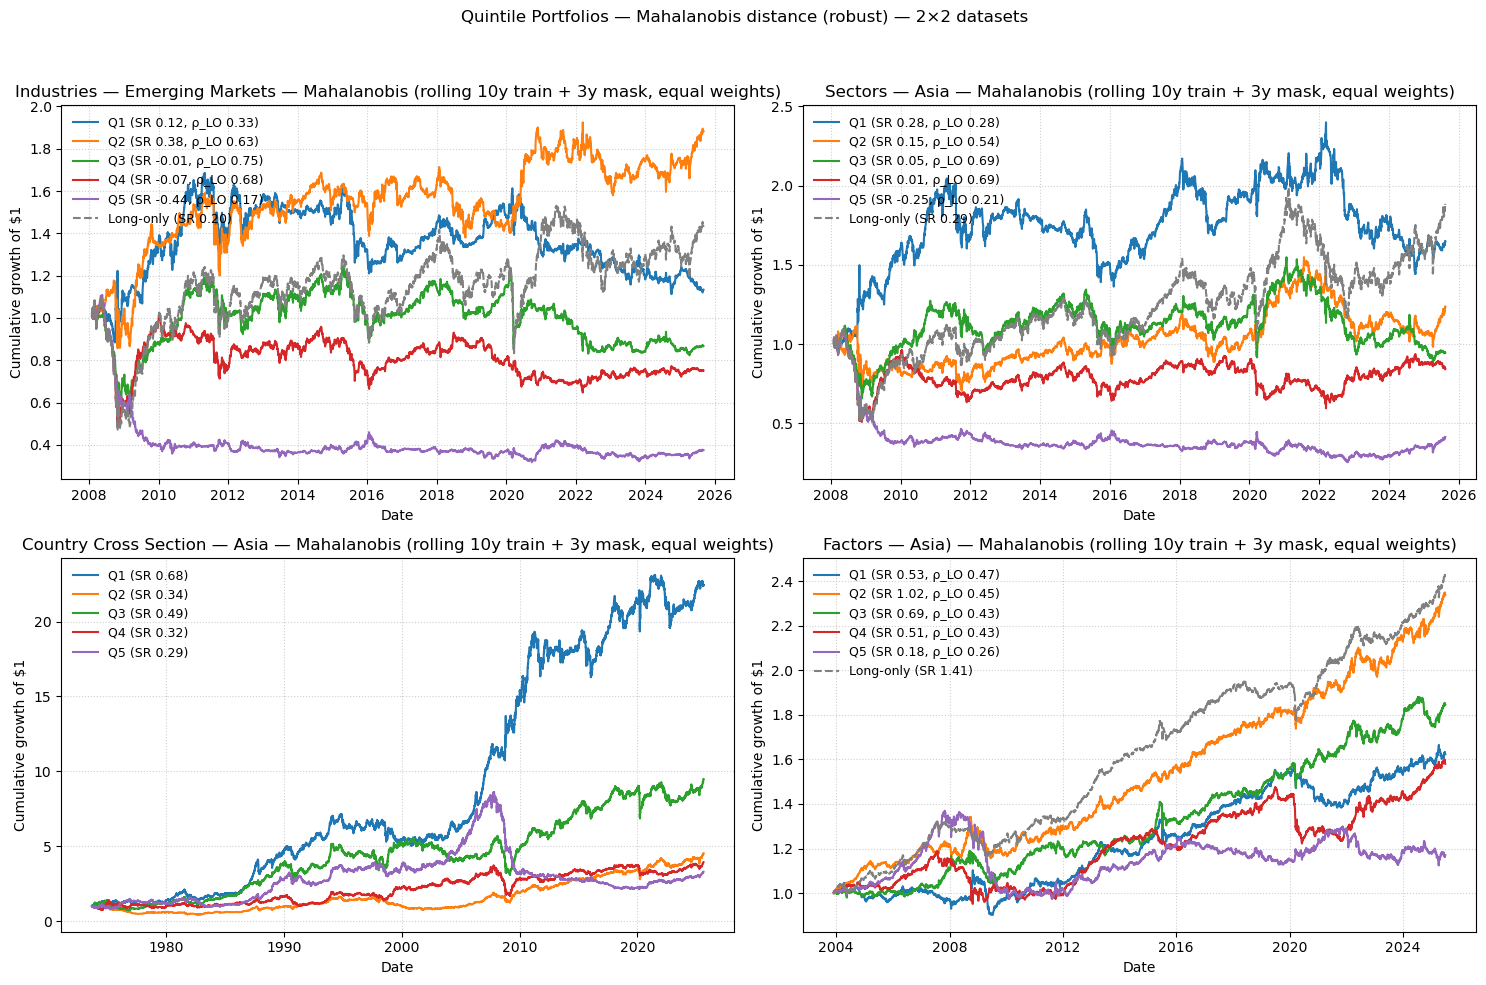

In [6]:
DATASETS = [
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Industries\Emerging Mkt Industries.xlsx"),
     "auto", "Industries — Emerging Markets", True),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Sectors\Per Region\Sector Asia.xlsx"),
     "auto", "Sectors — Asia", True),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Cross Section Countries\Asia CS Country.xlsx"),
     "auto", "Country Cross Section — Asia", False),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Asia\FF6_Asian_daily_cleaned.xlsx"),
     "auto", "Factors — Asia)", True),
]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PATH_MACRO = Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\state_z_america.xlsx")

TRAIN_YEARS = 10
MASK_YEARS  = 3

MIN_COVERAGE = 1.0  


def ann_sr(s: pd.Series) -> float:
    s = pd.Series(s).dropna()
    if s.empty: return np.nan
    sig = s.std()
    return (s.mean()/sig)*np.sqrt(252) if sig != 0 else np.nan

def clean_corr(a: pd.Series, b: pd.Series) -> float:
    df = pd.concat([a, b], axis=1).dropna()
    df = df[(df != 0).any(axis=1)]
    return df.corr().iloc[0,1] if not df.empty else np.nan

def make_quintiles(ordered_months):
    n = len(ordered_months)
    if n == 0: return {1:[],2:[],3:[],4:[],5:[]}
    k20 = max(int(0.20*n), 1)
    q1 = ordered_months[:k20]
    q5 = ordered_months[-k20:]
    mid = ordered_months[k20:-k20]
    if len(mid) >= 3:
        q2, q3, q4 = np.array_split(np.array(mid), 3)
    else:
        q2, q3, q4 = [], mid, []
    return {1:list(q1),2:list(q2),3:list(q3),4:list(q4),5:list(q5)}


def load_macro_states(path_macro: Path) -> pd.DataFrame:
    Z = pd.read_excel(path_macro)
    if "Month" not in Z.columns:
        for cand in ["month","MONTH","Date","Dates"]:
            if cand in Z.columns:
                Z = Z.rename(columns={cand: "Month"})
                break
    if "Month" not in Z.columns:
        raise ValueError("Macro file must have a 'Month' column (or Date/Dates).")
    Z["Month"] = pd.to_datetime(Z["Month"], errors="coerce").dt.to_period("M")
    Z = Z.set_index("Month").sort_index()
    macro_cols = [c for c in Z.columns if pd.api.types.is_numeric_dtype(Z[c])]
    if not macro_cols:
        raise ValueError("No numeric macro columns found in macro file.")
    return Z[macro_cols].astype(float)

def _parse_date_column(df: pd.DataFrame) -> pd.DatetimeIndex:
    date_col = next((c for c in ["Dates", "Date", "DATE", "date", "dt"] if c in df.columns), None)
    if date_col is None:
        raise ValueError("No date column named Dates/Date/DATE/date/dt found.")
    col = df[date_col]
    if np.issubdtype(col.dtype, np.datetime64):
        dt = pd.to_datetime(col, errors="coerce")
    else:
        as_str = col.astype(str).str.strip()
        if as_str.str.fullmatch(r"\d{8}").fillna(False).all():
            dt = pd.to_datetime(as_str, format="%Y%m%d", errors="coerce")
        else:
            dt = pd.to_datetime(col, errors="coerce")
    if dt.isna().all():
        raise ValueError("All dates failed to parse. Check the date format.")
    return dt

def load_assets_auto(path: Path, min_coverage: float = MIN_COVERAGE):

    df = pd.read_excel(path)
    df.columns = [c.strip() for c in df.columns]
    std_cols = ["Mkt-RF","SMB","HML","RMW","CMA","Mom","RF"]
    present  = [c for c in std_cols if c in df.columns]

    dt = _parse_date_column(df)
    date_col = next(c for c in ["Dates", "Date", "DATE", "date", "dt"] if c in df.columns)
    df = df.assign(**{date_col: dt}).dropna(subset=[date_col]).set_index(date_col).sort_index()

    if len(present) >= 5:
        sample = df[present].select_dtypes(include=[np.number]).stack()
        if sample.abs().median() > 0.05:
            df[present] = df[present].astype(float) / 100.0
        else:
            df[present] = df[present].astype(float)
        assets = [c for c in present if c != "RF"]
        sec_ret_daily   = df[assets].replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)
        sec_ret_monthly = (1.0 + sec_ret_daily).resample("ME").prod() - 1.0
    else:
        assets = [c for c in df.columns if c not in ["Dates","Date","DATE","date","dt"]
                  and pd.api.types.is_numeric_dtype(df[c])]
        if not assets:
            raise ValueError(f"No numeric asset columns found in {path.name}")
        sec_ret_daily   = df[assets].pct_change().replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)
        sec_ret_monthly = (1.0 + sec_ret_daily).resample("ME").prod() - 1.0

    need = max(1, int(np.ceil(min_coverage * len(assets))))
    good_months = sec_ret_monthly.notna().sum(axis=1) >= need
    sec_ret_monthly = sec_ret_monthly.loc[good_months]
    sector_months   = sec_ret_monthly.index.to_period("M")

    keep = sec_ret_daily.index.to_period("M").isin(sector_months)
    sec_ret_daily = sec_ret_daily.loc[keep]

    sec_ret_monthly.index = sec_ret_monthly.index.to_period("M")
    return sec_ret_daily, sec_ret_monthly, assets, sector_months


def mahalanobis_distances(F_train: pd.DataFrame, x0: pd.Series, ridge: float = 1e-8) -> pd.Series:

    common = F_train.columns.intersection(x0.index)
    if len(common) == 0 or F_train.shape[0] == 0:
        return pd.Series(dtype=float)

    X = F_train[common].values.astype(float)     # (n, p)
    x = x0[common].values.astype(float).reshape(1, -1)

    if X.shape[1] == 0:
        return pd.Series(dtype=float)

    Σ = np.cov(X, rowvar=False)
    Σ = np.atleast_2d(np.asarray(Σ))

    p = Σ.shape[0]
    if Σ.shape[0] != Σ.shape[1] or p != X.shape[1]:
        var = X.var(axis=0, ddof=1)
        var[var <= 0] = ridge
        Σ = np.diag(var)
        p = Σ.shape[0]

    Σ = Σ + ridge * np.eye(p)

    try:
        Σ_inv = np.linalg.inv(Σ)
    except np.linalg.LinAlgError:
        Σ_inv = np.linalg.pinv(Σ)

    diffs = X - x
    d2 = np.einsum("ij,jk,ik->i", diffs, Σ_inv, diffs)
    d = np.sqrt(np.clip(d2, 0, np.inf))
    return pd.Series(d, index=F_train.index).sort_values()

def build_quintile_series_rolling_maha_equal(path: Path,
                                             train_years: int = TRAIN_YEARS,
                                             mask_years: int  = MASK_YEARS,
                                             min_coverage: float = MIN_COVERAGE):
    sec_ret_daily, sec_ret_monthly, assets, sector_months = load_assets_auto(path, min_coverage=min_coverage)

    Z_all = load_macro_states(PATH_MACRO)
    Z = Z_all.reindex(sector_months).ffill()

    min_m = max(sector_months.min(), Z.index.min())
    first_eval = (min_m.asfreq("M") + (train_years + mask_years) * 12)
    months_bt = sector_months[(sector_months >= first_eval)]

    returns_by_q = {q: [] for q in range(1,6)}  

    for m in months_bt:
        tr_end   = (m - mask_years)             
        tr_start = tr_end - (train_years * 12) + 1

        F_train = Z.loc[(Z.index >= tr_start) & (Z.index <= tr_end)].dropna(how="any")
        if F_train.shape[0] < 2:   
            continue

        x0 = Z.loc[m].dropna()
        if x0.empty:
            continue

        d = mahalanobis_distances(F_train, x0, ridge=1e-8)
        if d.empty:
            continue

        buckets = make_quintiles(list(d.index))

        next_m = m + 1
        dts = sec_ret_daily.index[sec_ret_daily.index.to_period("M") == next_m]
        if len(dts) == 0:
            continue
        Rm = sec_ret_daily.loc[dts, assets]

        for q in [1,2,3,4,5]:
            q_months = buckets[q]
            if len(q_months) == 0:
                q_daily = pd.Series(0.0, index=dts)
            else:
                idx_sim_next = (pd.PeriodIndex(q_months, freq="M") + 1)
                idx_sim_next = sec_ret_monthly.index.intersection(idx_sim_next)
                if len(idx_sim_next) == 0:
                    q_daily = pd.Series(0.0, index=dts)
                else:
                    signs = {}
                    for a in assets:
                        mu = sec_ret_monthly.loc[idx_sim_next, a].mean()
                        signs[a] = np.sign(mu) if np.isfinite(mu) else 0.0
                    w_assets = pd.Series(signs, index=assets, dtype=float)
                    q_daily = (Rm * w_assets).mean(axis=1)

            returns_by_q[q].extend(q_daily.items())

    q_series = {q: pd.Series(dict(returns_by_q[q])).sort_index() for q in range(1,6)}
    for q in q_series:
        q_series[q].index = pd.to_datetime(q_series[q].index)

    common_idx = None
    for q in q_series:
        idx = q_series[q].index
        common_idx = idx if common_idx is None else common_idx.intersection(idx)
    for q in q_series:
        q_series[q] = q_series[q].reindex(common_idx).fillna(0.0)

    long_only = sec_ret_daily[assets].mean(axis=1).reindex(common_idx).fillna(0.0)

    return q_series, long_only

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=False)
axes = axes.ravel()

for ax, (path, kind, title, show_lo) in zip(axes, DATASETS):
    q_series, long_only = build_quintile_series_rolling_maha_equal(
        path=path,
        train_years=TRAIN_YEARS,
        mask_years=MASK_YEARS,
        min_coverage=MIN_COVERAGE
    )

    for q in [1,2,3,4,5]:
        sr = ann_sr(q_series[q])
        if show_lo:
            rho = clean_corr(q_series[q], long_only)
            lbl = f"Q{q} (SR {sr:.2f}, ρ_LO {rho:.2f})"
        else:
            lbl = f"Q{q} (SR {sr:.2f})"
        ax.plot(q_series[q].index, (1+q_series[q]).cumprod(), label=lbl)

    if show_lo:
        sr_lo = ann_sr(long_only)
        ax.plot(long_only.index, (1+long_only).cumprod(), color="gray", ls="--",
                label=f"Long-only (SR {sr_lo:.2f})")

    ax.set_title(f"{title} — Mahalanobis (rolling {TRAIN_YEARS}y train + {MASK_YEARS}y mask, equal weights)")
    ax.set_xlabel("Date"); ax.set_ylabel("Cumulative growth of $1")
    ax.grid(ls=":", alpha=.6)
    ax.legend(frameon=False, loc="upper left", fontsize=9)

plt.suptitle("Quintile Portfolios — Mahalanobis distance (robust) — 2×2 datasets", y=0.98)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


In [9]:
plt.savefig(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Research Notebook\Countries\figures\maha_asia")

<Figure size 640x480 with 0 Axes>

C:\Users\kelvi\AppData\Local\Temp\ipykernel_47352\2597176156.py:126: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  sec_ret_daily   = df[assets].pct_change().replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)


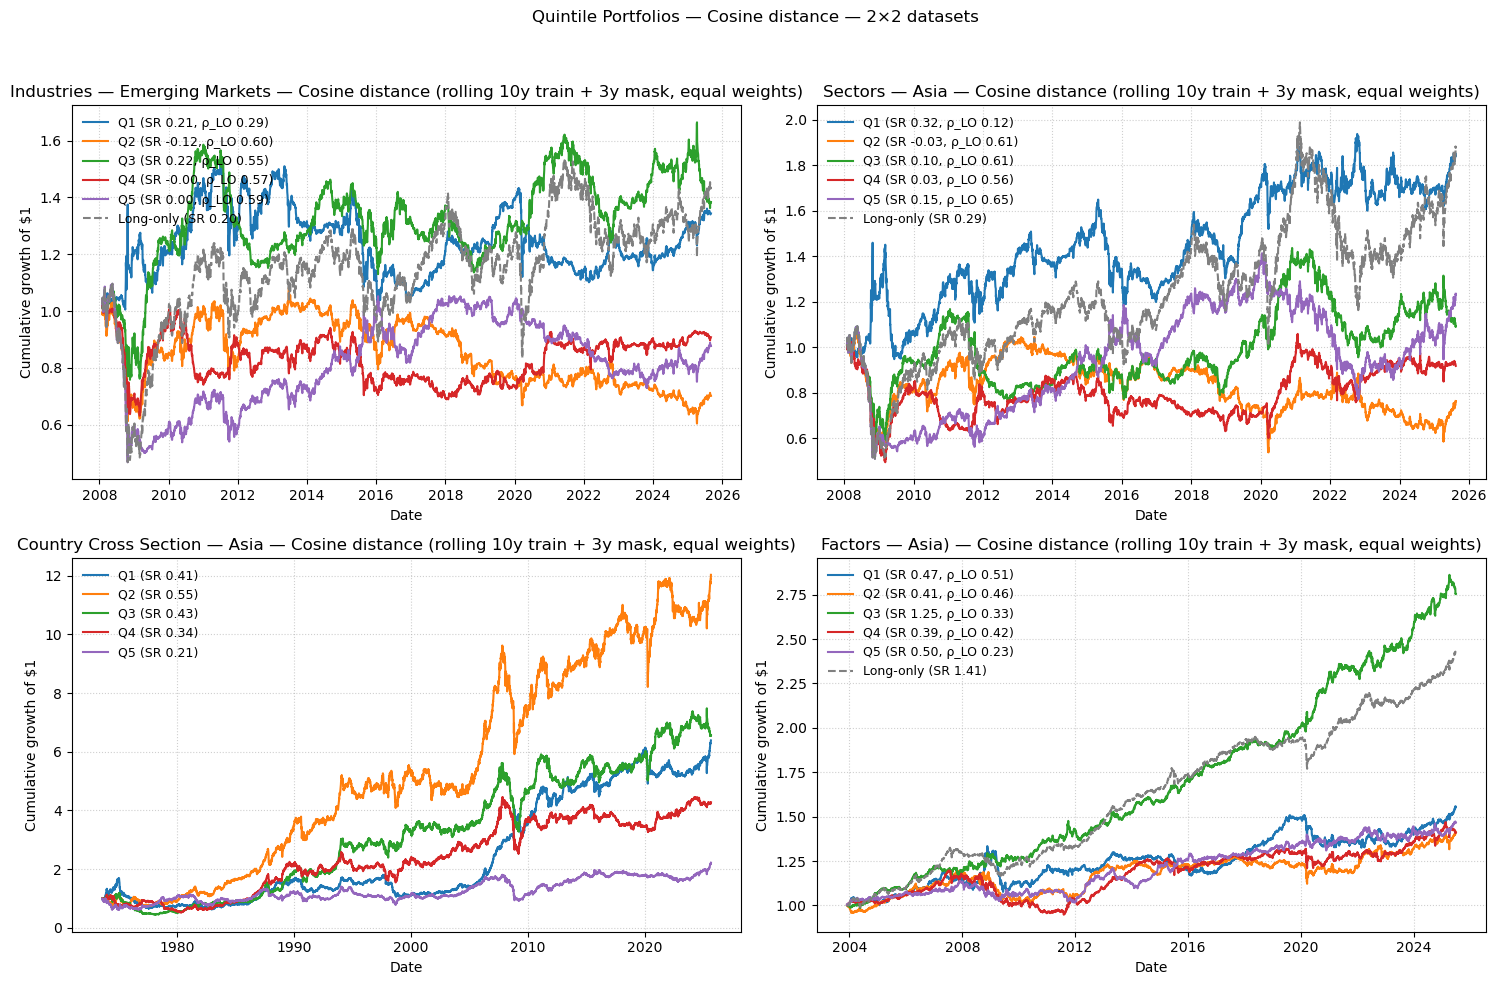

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
DATASETS = [
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Industries\Emerging Mkt Industries.xlsx"),
     "auto", "Industries — Emerging Markets", True),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Sectors\Per Region\Sector Asia.xlsx"),
     "auto", "Sectors — Asia", True),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Cross Section Countries\Asia CS Country.xlsx"),
     "auto", "Country Cross Section — Asia", False),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Asia\FF6_Asian_daily_cleaned.xlsx"),
     "auto", "Factors — Asia)", True),
]

PATH_MACRO = Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\state_z_america.xlsx")



TRAIN_YEARS = 10
MASK_YEARS  = 3

MIN_COVERAGE = 1.0  


def ann_sr(s: pd.Series) -> float:
    s = pd.Series(s).dropna()
    if s.empty: return np.nan
    sig = s.std()
    return (s.mean()/sig)*np.sqrt(252) if sig != 0 else np.nan

def clean_corr(a: pd.Series, b: pd.Series) -> float:
    df = pd.concat([a, b], axis=1).dropna()
    df = df[(df != 0).any(axis=1)]
    return df.corr().iloc[0,1] if not df.empty else np.nan

def make_quintiles(ordered_months):
    n = len(ordered_months)
    if n == 0: return {1:[],2:[],3:[],4:[],5:[]}
    k20 = max(int(0.20*n), 1)
    q1 = ordered_months[:k20]
    q5 = ordered_months[-k20:]
    mid = ordered_months[k20:-k20]
    if len(mid) >= 3:
        q2, q3, q4 = np.array_split(np.array(mid), 3)
    else:
        q2, q3, q4 = [], mid, []
    return {1:list(q1),2:list(q2),3:list(q3),4:list(q4),5:list(q5)}


def load_macro_states(path_macro: Path) -> pd.DataFrame:
    Z = pd.read_excel(path_macro)
    if "Month" not in Z.columns:
        for cand in ["month","MONTH","Date","Dates"]:
            if cand in Z.columns:
                Z = Z.rename(columns={cand: "Month"})
                break
    if "Month" not in Z.columns:
        raise ValueError("Macro file must have a 'Month' column (or Date/Dates).")
    Z["Month"] = pd.to_datetime(Z["Month"], errors="coerce").dt.to_period("M")
    Z = Z.set_index("Month").sort_index()
    macro_cols = [c for c in Z.columns if pd.api.types.is_numeric_dtype(Z[c])]
    if not macro_cols:
        raise ValueError("No numeric macro columns found in macro file.")
    return Z[macro_cols].astype(float)

def _parse_date_column(df: pd.DataFrame) -> pd.DatetimeIndex:
    date_col = next((c for c in ["Dates", "Date", "DATE", "date", "dt"] if c in df.columns), None)
    if date_col is None:
        raise ValueError("No date column named Dates/Date/DATE/date/dt found.")
    col = df[date_col]
    if np.issubdtype(col.dtype, np.datetime64):
        dt = pd.to_datetime(col, errors="coerce")
    else:
        as_str = col.astype(str).str.strip()
        if as_str.str.fullmatch(r"\d{8}").fillna(False).all():
            dt = pd.to_datetime(as_str, format="%Y%m%d", errors="coerce")
        else:
            dt = pd.to_datetime(col, errors="coerce")
    if dt.isna().all():
        raise ValueError("All dates failed to parse. Check the date format.")
    return dt

def load_assets_auto(path: Path, min_coverage: float = MIN_COVERAGE):

    df = pd.read_excel(path)
    df.columns = [c.strip() for c in df.columns]
    std_cols = ["Mkt-RF","SMB","HML","RMW","CMA","Mom","RF"]
    present  = [c for c in std_cols if c in df.columns]

    dt = _parse_date_column(df)
    date_col = next(c for c in ["Dates", "Date", "DATE", "date", "dt"] if c in df.columns)
    df = df.assign(**{date_col: dt}).dropna(subset=[date_col]).set_index(date_col).sort_index()

    if len(present) >= 5:
        sample = df[present].select_dtypes(include=[np.number]).stack()
        if sample.abs().median() > 0.05:
            df[present] = df[present].astype(float) / 100.0
        else:
            df[present] = df[present].astype(float)
        assets = [c for c in present if c != "RF"]
        sec_ret_daily   = df[assets].replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)
        sec_ret_monthly = (1.0 + sec_ret_daily).resample("ME").prod() - 1.0
    else:
        assets = [c for c in df.columns if c not in ["Dates","Date","DATE","date","dt"]
                  and pd.api.types.is_numeric_dtype(df[c])]
        if not assets:
            raise ValueError(f"No numeric asset columns found in {path.name}")
        sec_ret_daily   = df[assets].pct_change().replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)
        sec_ret_monthly = (1.0 + sec_ret_daily).resample("ME").prod() - 1.0

    need = max(1, int(np.ceil(min_coverage * len(assets))))
    good_months = sec_ret_monthly.notna().sum(axis=1) >= need
    sec_ret_monthly = sec_ret_monthly.loc[good_months]
    sector_months   = sec_ret_monthly.index.to_period("M")

    keep = sec_ret_daily.index.to_period("M").isin(sector_months)
    sec_ret_daily = sec_ret_daily.loc[keep]

    sec_ret_monthly.index = sec_ret_monthly.index.to_period("M")
    return sec_ret_daily, sec_ret_monthly, assets, sector_months


def cosine_distances(F_train: pd.DataFrame, x0: pd.Series, eps: float = 1e-12) -> pd.Series:

    common = F_train.columns.intersection(x0.index)
    if len(common) == 0 or F_train.shape[0] == 0:
        return pd.Series(dtype=float)

    X = F_train[common].values.astype(float)  
    v = x0[common].values.astype(float)      

    X_norm = np.linalg.norm(X, axis=1)
    v_norm = np.linalg.norm(v)

    valid = (X_norm > eps) & (v_norm > eps)
    if not np.any(valid):
        return pd.Series(dtype=float)

    sim = np.empty(X.shape[0])
    sim[:] = np.nan
    sim[valid] = (X[valid] @ v) / (X_norm[valid] * v_norm)
    dist = 1.0 - np.clip(sim, -1.0, 1.0)

    out = pd.Series(dist, index=F_train.index)
    out = out.replace([np.inf, -np.inf], np.nan).dropna().sort_values()
    return out


def build_quintile_series_rolling_cosine_equal(path: Path,
                                               train_years: int = TRAIN_YEARS,
                                               mask_years: int  = MASK_YEARS,
                                               min_coverage: float = MIN_COVERAGE):
    sec_ret_daily, sec_ret_monthly, assets, sector_months = load_assets_auto(path, min_coverage=min_coverage)

    Z_all = load_macro_states(PATH_MACRO)
    Z = Z_all.reindex(sector_months).ffill()

    min_m = max(sector_months.min(), Z.index.min())
    first_eval = (min_m.asfreq("M") + (train_years + mask_years) * 12)
    months_bt = sector_months[(sector_months >= first_eval)]

    returns_by_q = {q: [] for q in range(1,6)} 

    for m in months_bt:
        tr_end   = (m - mask_years)             
        tr_start = tr_end - (train_years * 12) + 1

        F_train = Z.loc[(Z.index >= tr_start) & (Z.index <= tr_end)].dropna(how="any")
        if F_train.shape[0] < 1:
            continue

        if m not in Z.index: 
            continue
        x0 = Z.loc[m].dropna()
        if x0.empty:
            continue

        d = cosine_distances(F_train, x0)
        if d.empty:
            continue

        buckets = make_quintiles(list(d.index))

        next_m = m + 1
        dts = sec_ret_daily.index[sec_ret_daily.index.to_period("M") == next_m]
        if len(dts) == 0:
            continue
        Rm = sec_ret_daily.loc[dts, assets]

        for q in [1,2,3,4,5]:
            q_months = buckets[q]
            if len(q_months) == 0:
                q_daily = pd.Series(0.0, index=dts)
            else:
                idx_sim_next = (pd.PeriodIndex(q_months, freq="M") + 1)
                idx_sim_next = sec_ret_monthly.index.intersection(idx_sim_next)
                if len(idx_sim_next) == 0:
                    q_daily = pd.Series(0.0, index=dts)
                else:
                    signs = {}
                    for a in assets:
                        mu = sec_ret_monthly.loc[idx_sim_next, a].mean()
                        signs[a] = np.sign(mu) if np.isfinite(mu) else 0.0
                    w_assets = pd.Series(signs, index=assets, dtype=float)
                    q_daily = (Rm * w_assets).mean(axis=1)

            returns_by_q[q].extend(q_daily.items())

    q_series = {q: pd.Series(dict(returns_by_q[q])).sort_index() for q in range(1,6)}
    for q in q_series:
        q_series[q].index = pd.to_datetime(q_series[q].index)

    common_idx = None
    for q in q_series:
        idx = q_series[q].index
        common_idx = idx if common_idx is None else common_idx.intersection(idx)
    for q in q_series:
        q_series[q] = q_series[q].reindex(common_idx).fillna(0.0)

    long_only = sec_ret_daily[assets].mean(axis=1).reindex(common_idx).fillna(0.0)

    return q_series, long_only


fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=False)
axes = axes.ravel()

for ax, (path, kind, title, show_lo) in zip(axes, DATASETS):
    q_series, long_only = build_quintile_series_rolling_cosine_equal(
        path=path,
        train_years=TRAIN_YEARS,
        mask_years=MASK_YEARS,
        min_coverage=MIN_COVERAGE
    )

    for q in [1,2,3,4,5]:
        sr = ann_sr(q_series[q])
        if show_lo:
            rho = clean_corr(q_series[q], long_only)
            lbl = f"Q{q} (SR {sr:.2f}, ρ_LO {rho:.2f})"
        else:
            lbl = f"Q{q} (SR {sr:.2f})"
        ax.plot(q_series[q].index, (1+q_series[q]).cumprod(), label=lbl)

    if show_lo:
        sr_lo = ann_sr(long_only)
        ax.plot(long_only.index, (1+long_only).cumprod(), color="gray", ls="--",
                label=f"Long-only (SR {sr_lo:.2f})")

    ax.set_title(f"{title} — Cosine distance (rolling {TRAIN_YEARS}y train + {MASK_YEARS}y mask, equal weights)")
    ax.set_xlabel("Date"); ax.set_ylabel("Cumulative growth of $1")
    ax.grid(ls=":", alpha=.6)
    ax.legend(frameon=False, loc="upper left", fontsize=9)

plt.suptitle("Quintile Portfolios — Cosine distance — 2×2 datasets", y=0.98)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()
